<center><h1> Forward Process <h1><center>

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
from pathlib import Path

def print_tree(root=".", prefix="", ignore={".git", "__pycache__", ".ipynb_checkpoints", ".venv", "venv", "node_modules"}):
    root = Path(root)
    entries = sorted([e for e in root.iterdir() if e.name not in ignore],
                      key=lambda e: (e.is_file(), e.name.lower()))
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(prefix + connector + entry.name)
        if entry.is_dir():
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, prefix + extension, ignore)

print_tree(".")

├── docs
│   ├── 01. Diffusion
│   │   ├── Cao et al. (2024), A Survey on Generative Diffusion Models.pdf
│   │   ├── Chen et al. (2024), An Overview of Diffusion Models Applications, Guided Generation, Statistical Rates and Optimization.pdf
│   │   ├── Ho et al. (2020), Denoising Diffusion Probabilistic Models.pdf
│   │   ├── Ho et al. (2022), Classifier Free Diffusion Guidance.pdf
│   │   ├── Kingma et al. (2022), Variational Diffusion Models.pdf
│   │   ├── Luo (2022), Understanding Diffusion Models A Unified Perspective.pdf
│   │   ├── Nakkiran et al. (2024) Step-by-Step Diffusion An Elementary Tutorial.pdf
│   │   ├── Nichol et Dhariwal (2021), Improved Denoising Diffusion Probabilistic Models.pdf
│   │   ├── Sohl Dickenstein et al. (2015), Deep Unsupervised Learning using Nonequilibrium Thermodynamics.pdf
│   │   ├── Song et al. (2021), Denoising Diffusion Implicit Models.pdf
│   │   ├── Song et al. (2021), Score-based Generative Models through SDE.pdf
│   │   ├── Song et Ermon (

In [ ]:
from src.diff.scheduler import BaseScheduler
import torch 
import matplotlib.pyplot as plt 
from typing import Final
import numpy as np
from src.diff.ddpm import DDPM 
from src.data.ar import ARMA 
from src.data.var import VAR 
from src.diff.noise_process import NoiseProcess 

In this notebook we study the characteristics of the forward process in the context of time series. In DDPM the forward process is fixed on a Markov Chain: 

$$ x_t^{(k)} = \sqrt{\beta_k} x^{(k-1)}_t + \sqrt{1 - \beta_k}z_k $$

where $z_k$ is a $\mathcal{N}(0,1)$ random variable. The reparametrized forward is easier to use: 

$$ x_t^{(k)} = \sqrt{\bar{\alpha}_k} x^{(0)}_t + \sqrt{1 - \bar{\alpha}_k}\epsilon $$

for $\alpha_k = 1 - \beta_k$ and $\bar{\alpha}_k = \prod_{i=1}^k\alpha_i $. 

# 1. Variance Schedule

One of the first things in diffusion models is to look at the variance schedule of the diffusion process. The two main used schedules are a) the Linear schedule; and b) the cosine schedule

In [ ]:
K = 100 
beta_1 = 1e-4
beta_K = 0.1 
s = 8e-3

In [8]:
linear_scheduler = BaseScheduler(K = K, 
                                beta_1 = beta_1, 
                                beta_K = beta_K, 
                                s = s,
                                mode = 'linear')

cosine_scheduler = BaseScheduler(K = K, 
                                beta_1 = beta_1, 
                                beta_K = beta_K, 
                                s = s,
                                mode = 'cosine')

forward_variance_ddpm = {'linear schedule' : linear_scheduler.alpha_bar, 
                            'cosine_schedule' : cosine_scheduler.alpha_bar
                            }

reverse_variance_ddpm = {'linear schedule' : linear_scheduler.beta_tilde, 
                                # 'cosine_schedule' : cosine_scheduler.beta_tilde
                                }

def plot_schedule(schedule : dict,
                  title : str, 
                  ylabel : str, 
                  xlabel : str,
                  figsize : tuple = (10,7),
                  fontsize : int = 18): 
    plt.figure(figsize=figsize)
    k = np.arange(1, K + 1)/K # Shift by one to have as in DDPM notation
    for legend, series in schedule.items():
        plt.plot(k, series.detach().numpy(), label = legend)
    plt.title(title, fontsize = fontsize)
    plt.ylabel(ylabel, fontsize = fontsize - 2)
    plt.xlabel(xlabel, fontsize = fontsize - 2)
    plt.legend(fontsize = fontsize - 4)
    plt.show()

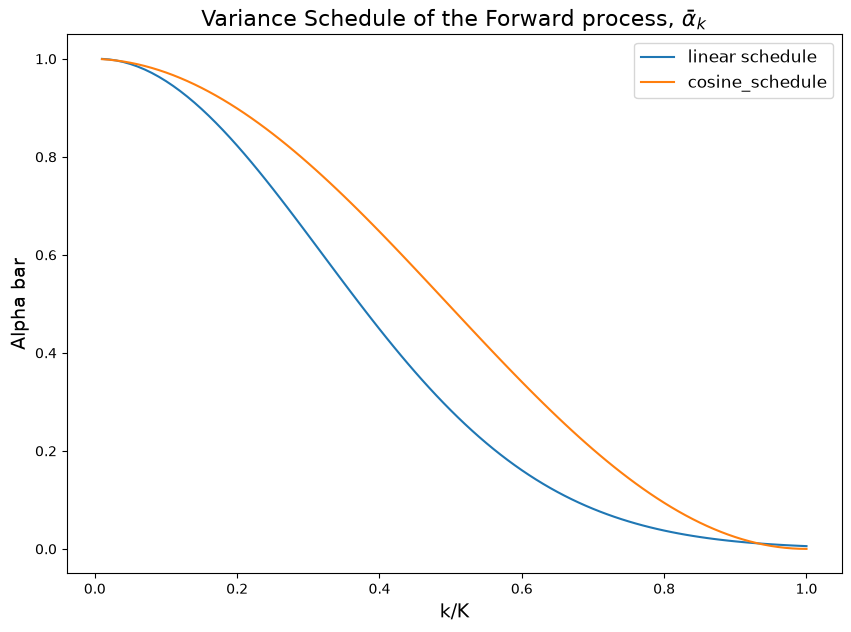

In [7]:
plot_schedule(forward_variance_ddpm, 
                title = r'Variance Schedule of the Forward process, $\bar{\alpha}_{k}$', 
                ylabel = 'Alpha bar', 
                xlabel = 'k/K',
                fontsize = 16)

Note $\tilde{\beta}_k \approx \beta_k$ everywhere except on $k \rightarrow 0$. 

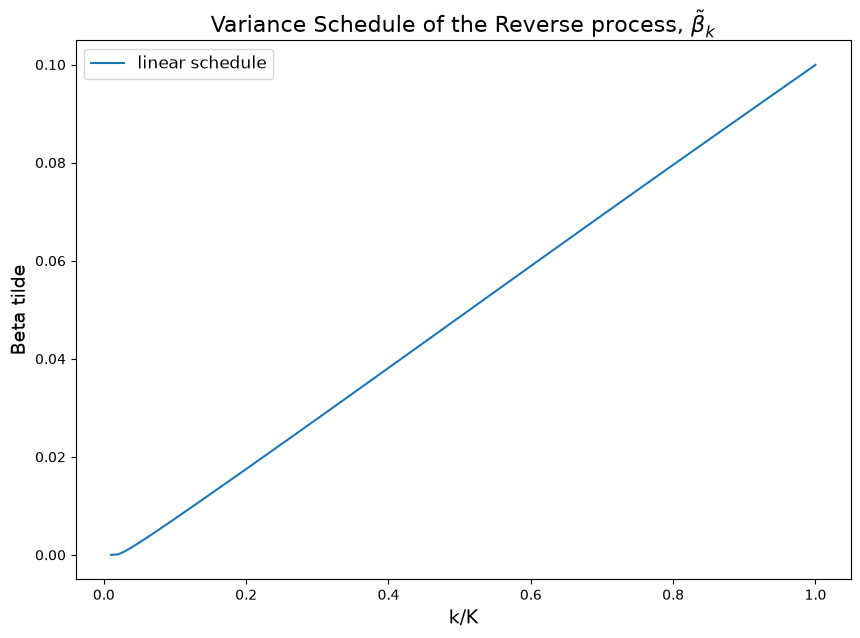

In [9]:
plot_schedule(reverse_variance_ddpm, 
                    title = r'Variance Schedule of the Reverse process, $\tilde{\beta}_{k}$', 
                    ylabel = 'Beta tilde', 
                    xlabel = 'k/K',
                    fontsize = 16
                    )

# 2. Forward Process

The forward process is described by the reparametrized diffusion equation. 

In [18]:
K = 100 
beta_1 = 1e-4
beta_K = 0.1 
s = 8e-3

T = 500
N = 3

In [17]:
scheduler = BaseScheduler(K = K, 
                          beta_1=beta_1, 
                          beta_K=beta_K,
                          mode = 'linear')
ddpm = DDPM(scheduler)

phi_coefs = [0.8]
ma_coefs = []

arma = ARMA(phi_coefs=phi_coefs, 
            ma_coefs=ma_coefs)

In [15]:
def plot_forward_process(
    y: torch.Tensor,
    noise: NoiseProcess,
    steps: list[int] = [0, 11, 49, 99],
):
    """
    Visualize the forward diffusion process at several timesteps k.

    Parameters
    ----------
    y : (T, N) tensor -- a single trajectory of length T with N covariates/dimensions.
    noise : object implementing q_sample(x_0, k) -> (x_k, added_noise).
    steps : which diffusion steps k to visualize, alongside the original (clean) series.
    """
    T, N = y.shape

    process_forw = {"Original": y.detach().numpy()}
    for k in steps:
        k_tensor = torch.full((T,), k, dtype=torch.long)
        x_k, _ = noise.q_sample(x_0=y, k=k_tensor)
        process_forw[f"k = {k + 1}"] = x_k.detach().numpy()

    n_cols = len(process_forw)
    fig, axes = plt.subplots(
        nrows=N, ncols=n_cols, figsize=(4 * n_cols, 2.5 * N),
        sharex=True, sharey="row", squeeze=False,
    )

    for j, (label, series) in enumerate(process_forw.items()):
        for d in range(N):
            ax = axes[d, j]
            ax.plot(series[:, d], alpha=0.8)
            if d == 0:
                ax.set_title(label)
            if j == 0:
                ax.set_ylabel(f"dim {d}" if N > 1 else "value")
            if d == N - 1:
                ax.set_xlabel("t")

    fig.suptitle("Forward diffusion process")
    fig.tight_layout()
    plt.show()

torch.Size([500, 1])


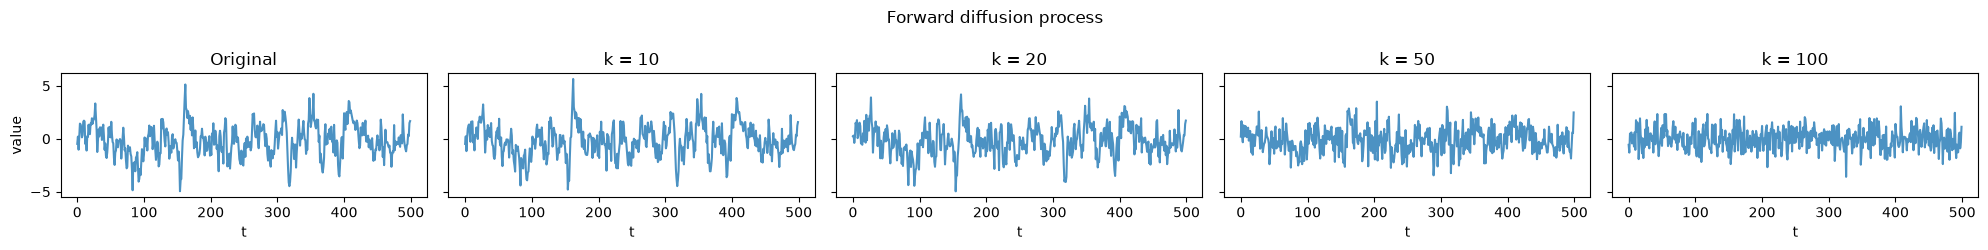

In [19]:
x_t = arma.generate_trajectory(T = T,)[0]
print(x_t.shape)
plot_forward_process(x_t, noise = ddpm, steps=[9, 19, 49, 99])